# Skin Cancer Classification — EDA & Preprocessing

**Dataset:** Skin Cancer Detection (local folder, `train` / `valid` / `test`, 7 lesion classes: `nv`, `bkl`, `mel`, `bcc`, `akiec`, `vasc`, `df`)

Sections: **1) Setup → 2) Data Loading → 3) Data Cleaning → 4) EDA → 5) Preprocessing**


## 1. Setup
Import the libraries used for file handling, data tables, plotting, and image processing.

In [4]:
import os
import glob
from pathlib import Path
DATASET_DIR = "Skin Cancer Detection"   # folder next to this notebook (train/valid/test)
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
np.random.seed(42)




ModuleNotFoundError: No module named 'cv2'

## 2. Data Loading
Scan `train`, `valid`, and `test` folders and build one DataFrame with each image's file path, class label, and split. This table is used for every step below instead of re-reading the folders each time.

In [5]:
records = []
for path in glob.glob(os.path.join(DATASET_DIR, "**", "*"), recursive=True):
    p = Path(path)
    if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
        split = next((s for s in ["train", "valid", "test"] if s in p.parts), "unknown")
        records.append({"filepath": str(p), "label": p.parent.name, "split": split})

df = pd.DataFrame(records)
print("Total images:", len(df))
df.head()


Total images: 16831


,filepath,label,split
0,Skin Cancer Detection\test\akiec\ISIC_0024562_...,akiec,test
1,Skin Cancer Detection\test\akiec\ISIC_0024646_...,akiec,test
2,Skin Cancer Detection\test\akiec\ISIC_0025247_...,akiec,test
3,Skin Cancer Detection\test\akiec\ISIC_0025539_...,akiec,test
4,Skin Cancer Detection\test\akiec\ISIC_0025637_...,akiec,test


## 3. Data Cleaning
Check for the three common issues that would break training: corrupted/unreadable files, zero-byte files, and duplicate images (hashed by content). Any bad rows found are dropped from `df`.

In [6]:
import hashlib

def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return os.path.getsize(path) > 0
    except Exception:
        return False

df["is_valid"] = df["filepath"].apply(is_valid_image)
n_corrupt = (~df["is_valid"]).sum()
print(f"Corrupted/unreadable files: {n_corrupt}")

df = df[df["is_valid"]].drop(columns=["is_valid"]).reset_index(drop=True)

# Duplicate check via MD5 hash of file bytes
def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

df["hash"] = df["filepath"].apply(file_hash)
n_dupes = df["hash"].duplicated().sum()
print(f"Duplicate images: {n_dupes}")

df = df.drop_duplicates(subset="hash").drop(columns=["hash"]).reset_index(drop=True)
print("Clean dataset size:", len(df))


Corrupted/unreadable files: 0
Duplicate images: 1
Clean dataset size: 16830


## 4. Exploratory Data Analysis

### 4.1 Class distribution
Count images per class and plot a bar chart and an indexed pie chart, both using a clear, distinct color palette so all 7 classes are easy to tell apart.

C:\Users\Asus\AppData\Local\Temp\ipykernel_17520\2116928004.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette=palette, ax=axes[0])


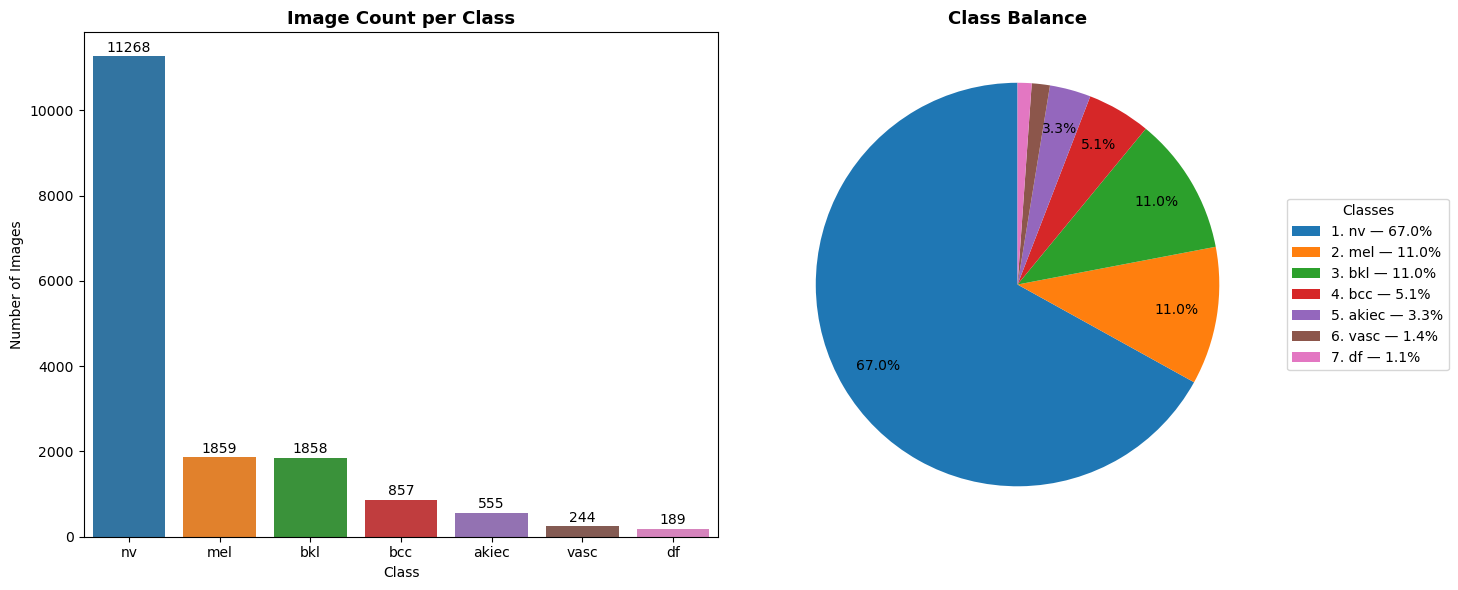

In [7]:
class_counts = df["label"].value_counts()
palette = sns.color_palette("tab10", n_colors=len(class_counts))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart
sns.barplot(x=class_counts.index, y=class_counts.values, palette=palette, ax=axes[0])
axes[0].set_title("Image Count per Class", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Images")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + max(class_counts.values) * 0.01, str(v), ha="center", fontsize=10)

# Indexed pie chart
labels_idx = [f"{i+1}. {lbl}" for i, lbl in enumerate(class_counts.index)]
percentages = class_counts.values / class_counts.values.sum() * 100
autopct_fn = lambda pct: f"{pct:.1f}%" if pct >= 3 else ""
wedges, _, _ = axes[1].pie(class_counts.values, autopct=autopct_fn, startangle=90,
                            colors=palette, pctdistance=0.8, textprops={"fontsize": 10})
legend_labels = [f"{i+1}. {lbl} — {pct:.1f}%" for i, (lbl, pct) in enumerate(zip(class_counts.index, percentages))]
axes[1].legend(wedges, legend_labels, title="Classes", loc="center left",
               bbox_to_anchor=(1.02, 0.5), fontsize=10)
axes[1].set_title("Class Balance", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()


### 4.2 Train / Valid / Test split per class
A stacked bar chart showing how each class is distributed across the three splits — confirms the splits are proportionate and no class is missing from any split.

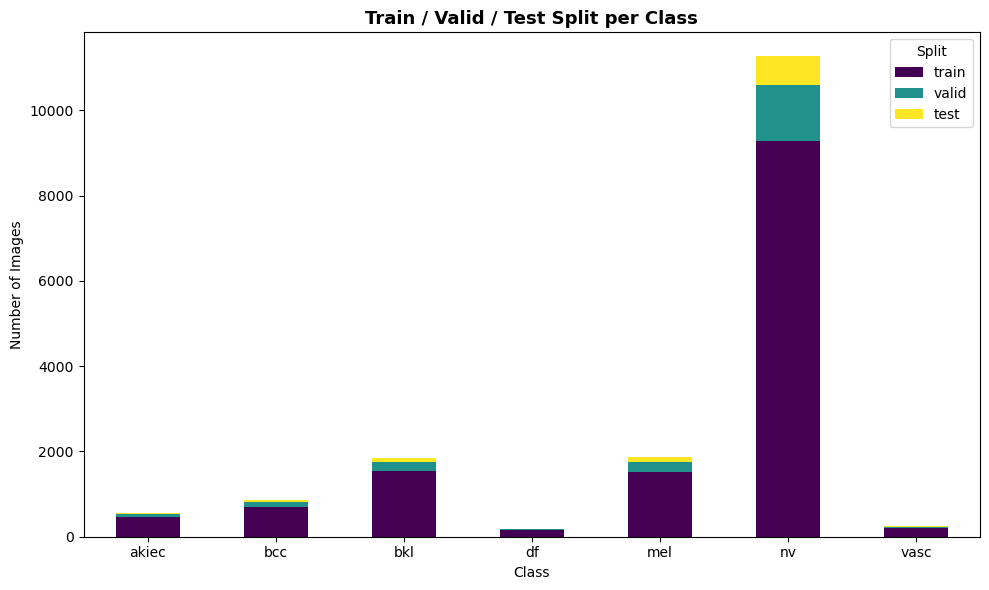

split,train,valid,test
label,,,
akiec,468,59,28
bcc,698,105,54
bkl,1545,202,111
df,148,30,11
mel,1522,226,111
nv,9274,1326,668
vasc,206,30,8


In [8]:
split_counts = df.groupby(["label", "split"]).size().unstack(fill_value=0)
split_counts = split_counts[["train", "valid", "test"]] if set(["train","valid","test"]).issubset(split_counts.columns) else split_counts

split_counts.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="viridis")
plt.title("Train / Valid / Test Split per Class", fontsize=13, fontweight="bold")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.legend(title="Split")
plt.tight_layout()
plt.show()

split_counts


### 4.3 Sample images per class
Display a few sample lesion images from each class in a grid, to visually confirm the labels look correct and see how the classes differ in appearance.

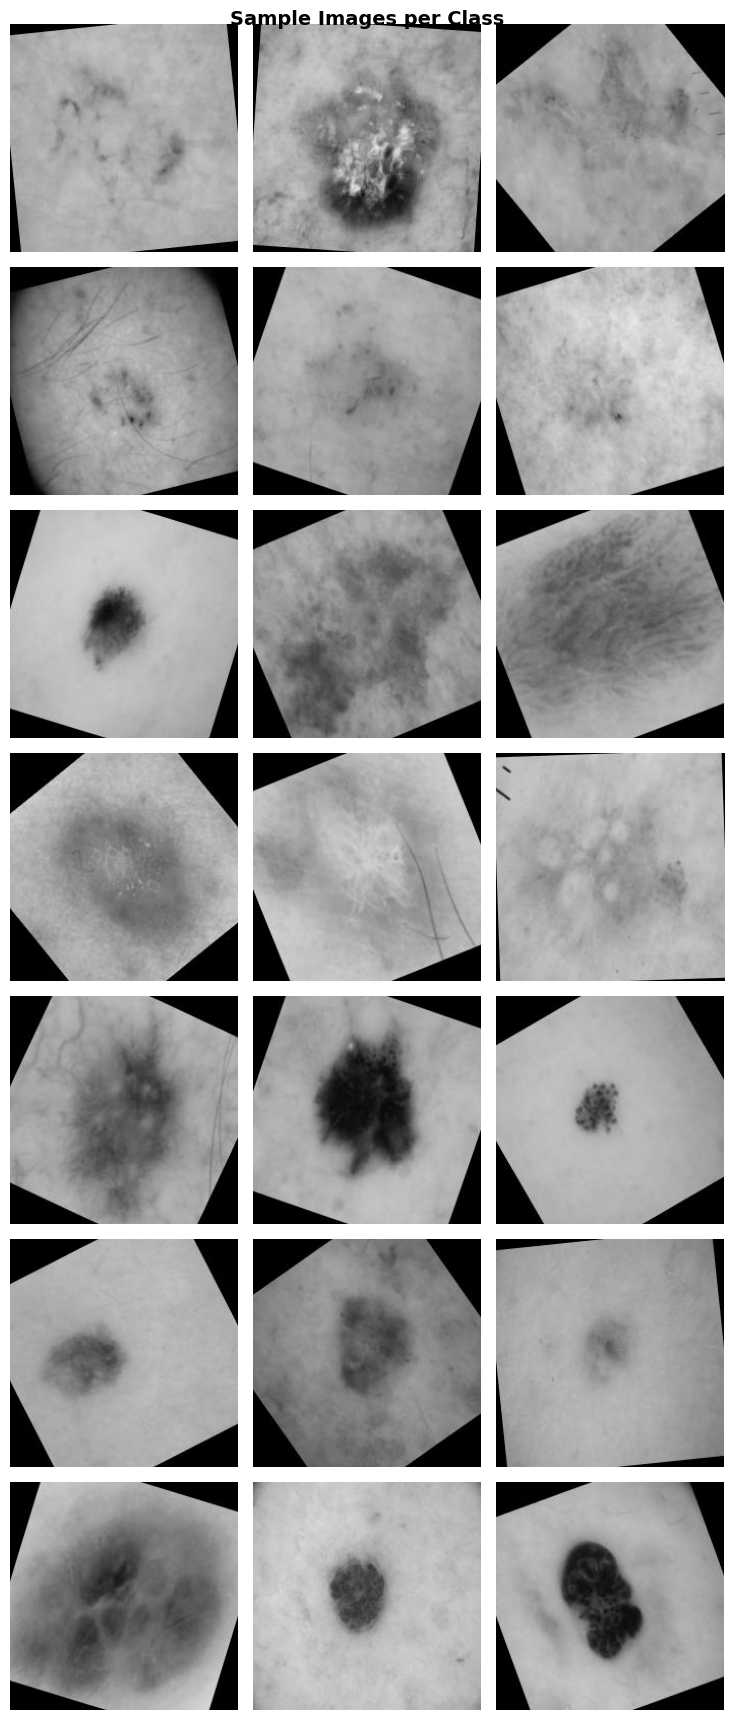

<Figure size 640x480 with 0 Axes>

In [ ]:
classes = sorted(df["label"].unique())
n_samples = 3

fig, axes = plt.subplots(len(classes), n_samples, figsize=(n_samples * 2.5, len(classes) * 2.5))
for i, cls in enumerate(classes):
    paths = df[df["label"] == cls]["filepath"].sample(n=min(n_samples, (df["label"] == cls).sum()), random_state=1)
    for j, p in enumerate(paths):
        img = Image.open(p).convert("RGB")
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
    axes[i, 0].set_ylabel(cls, fontsize=11, rotation=0, labelpad=40, va="center")

plt.suptitle("Sample Images per Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()



### 4.4 Image dimensions
Sample a subset of images and check their width/height, to see whether resizing is needed before feeding images into a model.

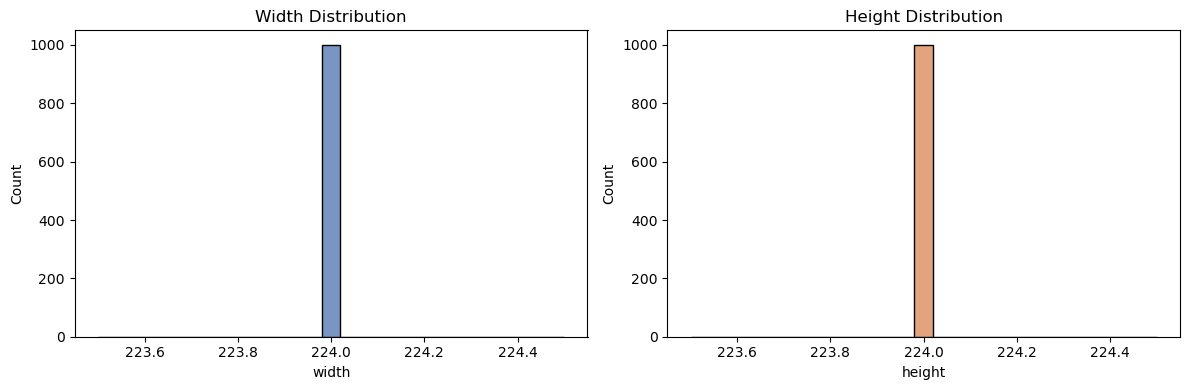

,width,height
count,1000.0,1000.0
mean,224.0,224.0
std,0.0,0.0
min,224.0,224.0
25%,224.0,224.0
50%,224.0,224.0
75%,224.0,224.0
max,224.0,224.0


In [15]:
sample_df = df.sample(n=min(1000, len(df)), random_state=42).copy()
sizes = sample_df["filepath"].apply(lambda p: Image.open(p).size)
sample_df["width"] = sizes.apply(lambda s: s[0])
sample_df["height"] = sizes.apply(lambda s: s[1])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(sample_df["width"], bins=25, color="#4C72B0", ax=axes[0])
axes[0].set_title("Width Distribution")
sns.histplot(sample_df["height"], bins=25, color="#DD8452", ax=axes[1])
axes[1].set_title("Height Distribution")
plt.tight_layout()
plt.show()

sample_df[["width", "height"]].describe()


### 4.5 Average color per class
Compute the mean RGB intensity per class to see if color alone shows any visible difference between lesion types — useful context since color is a diagnostic cue for skin lesions.

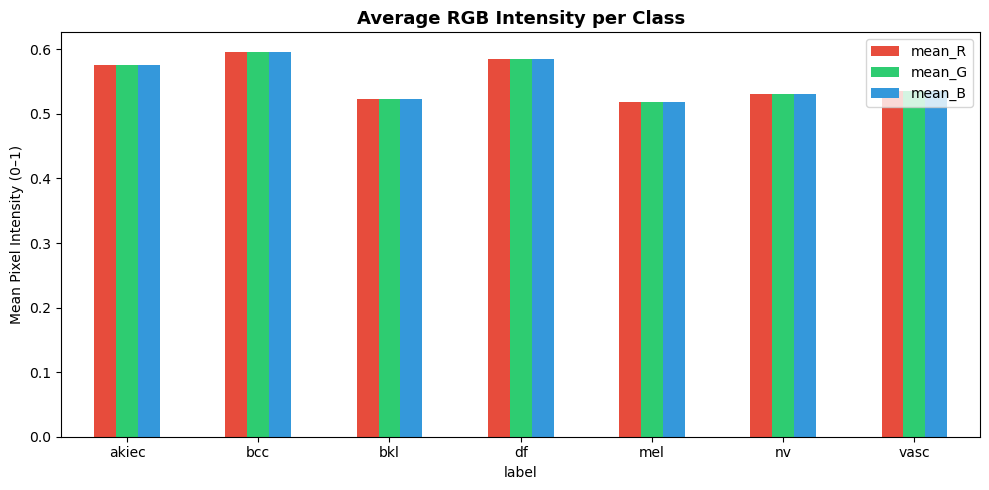

In [16]:
def mean_rgb(path, size=(64, 64)):
    arr = np.array(Image.open(path).convert("RGB").resize(size)) / 255.0
    return arr.reshape(-1, 3).mean(axis=0)

sample_df[["mean_R", "mean_G", "mean_B"]] = pd.DataFrame(
    sample_df["filepath"].apply(mean_rgb).tolist(), index=sample_df.index)

class_rgb = sample_df.groupby("label")[["mean_R", "mean_G", "mean_B"]].mean()

class_rgb.plot(kind="bar", figsize=(10, 5), color=["#E74C3C", "#2ECC71", "#3498DB"])
plt.title("Average RGB Intensity per Class", fontsize=13, fontweight="bold")
plt.ylabel("Mean Pixel Intensity (0–1)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 5. Data Preprocessing
Since the images vary in size and the classes are imbalanced (see 4.1), this cell defines a preprocessing function (resize + normalize) and computes class weights to correct the imbalance during model training in the next assignment.

In [17]:
IMG_SIZE = (128, 128)

def load_and_preprocess(path, size=IMG_SIZE):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    img = img / 255.0          # normalize to [0, 1]
    return img

# Quick check on one image
sample_img = load_and_preprocess(df["filepath"].iloc[0])
print("Preprocessed image shape:", sample_img.shape, "| value range:", sample_img.min(), "-", sample_img.max())

# Class weights to handle imbalance (inverse frequency)
class_counts_all = df["label"].value_counts()
total = len(df)
class_weights = {cls: total / (len(class_counts_all) * count) for cls, count in class_counts_all.items()}
pd.Series(class_weights, name="class_weight").sort_values(ascending=False)


NameError: name 'cv2' is not defined